# Classification binaire : Gravite (Grave vs Non grave)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du jeu de données

In [2]:
df = pd.read_csv("data/processed/accidents_encoded_ready.csv")

In [3]:
# 1. Création de la cible binaire
df['grav_binaire'] = df['grav'].apply(lambda x: 1 if x in [3, 4] else 0)

grav_binaire
0    0.82106
1    0.17894
Name: proportion, dtype: float64


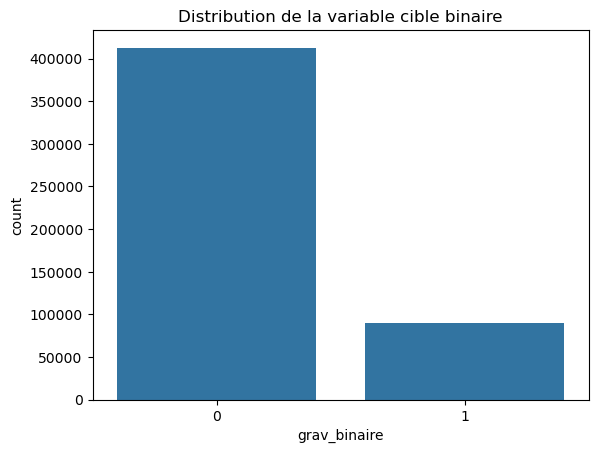

In [4]:
# 2. Vérification de la répartition
print(df['grav_binaire'].value_counts(normalize=True))
sns.countplot(x='grav_binaire', data=df)
plt.title("Distribution de la variable cible binaire")
plt.show()

#Déséquilibre important : la classe des accidents graves est nettement minoritaire.
#Cela peut biaiser l'entraînement (le modèle peut prédire uniquement la classe majoritaire).

In [5]:
# 3. Préparation des données
X = df.drop(columns=['grav', 'grav_binaire']) 
y = df['grav_binaire']

In [6]:
# Dummy encoding si besoin (ex : si variables catégorielles encore présentes)
X = pd.get_dummies(X, drop_first=True)

In [7]:
# 4. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [8]:
# 5. Entraînement Random Forest (baseline)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
# 6. Évaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("\nClassification Report :\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("\nROC AUC :", roc_auc_score(y_test, y_proba))


Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     82572
           1       0.62      0.37      0.47     17996

    accuracy                           0.85    100568
   macro avg       0.75      0.66      0.69    100568
weighted avg       0.83      0.85      0.83    100568


Confusion Matrix :
 [[78495  4077]
 [11273  6723]]

ROC AUC : 0.8516226836733363


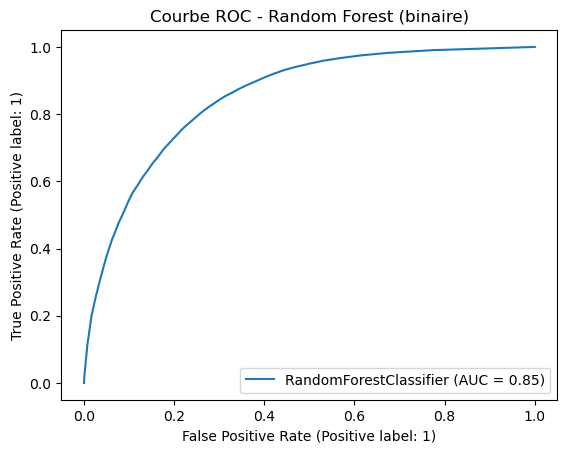

In [10]:
# Courbe ROC
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("Courbe ROC - Random Forest (binaire)")
plt.show()
#Objectif métier
#L'objectif n’est pas juste l’accuracy, mais repérer un maximum d'accidents graves (classe 1) → c’est un enjeu de sécurité.
#Le modèle binaire fonctionne globalement bien (AUC = 0.85) → il sait séparer les classes, c’est positif.
#Mais il est déséquilibré : il privilégie la classe 0 (accidents non graves).

In [11]:
#  Modèle de base : Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
# Prédictions et probabilités
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("--- Logistic Regression ---")
print("Classification Report :\n", classification_report(y_test, y_pred))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred))
print("ROC AUC :", roc_auc_score(y_test, y_proba))


--- Logistic Regression ---
Classification Report :
               precision    recall  f1-score   support

           0       0.83      0.98      0.90     82572
           1       0.53      0.11      0.18     17996

    accuracy                           0.82    100568
   macro avg       0.68      0.54      0.54    100568
weighted avg       0.78      0.82      0.77    100568

Confusion Matrix :
 [[80864  1708]
 [16081  1915]]
ROC AUC : 0.7540340934192431


In [13]:
# 4. Ajustement du seuil de décision
custom_threshold = 0.3
y_pred_thresh = (y_proba > custom_threshold).astype(int)

print("--- Logistic Regression (seuil 0.3) ---")
print("Classification Report :\n", classification_report(y_test, y_pred_thresh))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_thresh))

--- Logistic Regression (seuil 0.3) ---
Classification Report :
               precision    recall  f1-score   support

           0       0.87      0.88      0.88     82572
           1       0.42      0.39      0.41     17996

    accuracy                           0.80    100568
   macro avg       0.65      0.64      0.64    100568
weighted avg       0.79      0.80      0.79    100568

Confusion Matrix :
 [[72897  9675]
 [10920  7076]]


In [14]:
# 5. Logistic Regression avec class_weight='balanced'
model_bal = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_bal.fit(X_train, y_train)

y_pred_bal = model_bal.predict(X_test)
y_proba_bal = model_bal.predict_proba(X_test)[:, 1]

print("--- Logistic Regression (balanced) ---")
print("Classification Report :\n", classification_report(y_test, y_pred_bal))
print("Confusion Matrix :\n", confusion_matrix(y_test, y_pred_bal))
print("ROC AUC :", roc_auc_score(y_test, y_proba_bal))


--- Logistic Regression (balanced) ---
Classification Report :
               precision    recall  f1-score   support

           0       0.91      0.67      0.77     82572
           1       0.31      0.69      0.43     17996

    accuracy                           0.67    100568
   macro avg       0.61      0.68      0.60    100568
weighted avg       0.80      0.67      0.71    100568

Confusion Matrix :
 [[55101 27471]
 [ 5515 12481]]
ROC AUC : 0.7546014079899577


# Afin de pallier au fort déséquilibre des classes, nous avons testé plusieurs stratégies de classification binaire : un modèle standard, un modèle avec seuil ajusté, et un modèle pondéré.
Les résultats montrent que l’approche pondérée permet de détecter jusqu’à 69% des accidents graves (classe 1), au prix d’une baisse de précision.
Pour une politique de sécurité préventive, ce compromis peut être acceptable.
D’autres modèles plus puissants comme Random Forest ou XGBoost pourront encore améliorer les performances.

--- Random Forest (class_weight='balanced') ---
Classification Report :
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     82572
           1       0.63      0.35      0.45     17996

    accuracy                           0.85    100568
   macro avg       0.75      0.65      0.68    100568
weighted avg       0.83      0.85      0.83    100568



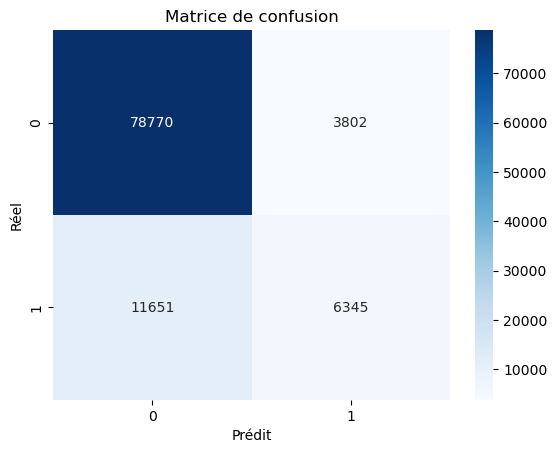

ROC AUC : 0.8503


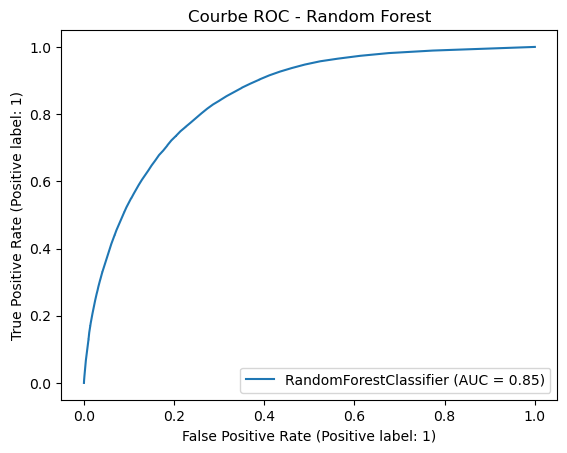

In [15]:
# Modèle Random Forest avec pondération automatique :Avec class_weight='balanced' pour compenser le déséquilibre entre les classes.
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Prédiction
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

# Rapport de classification
print("--- Random Forest (class_weight='balanced') ---")
print("Classification Report :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# ROC AUC
roc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC : {roc:.4f}")

# Courbe ROC
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("Courbe ROC - Random Forest")
plt.show()

Le modèle a bien identifié la majorité des cas non graves (classe 0).

Il commence à capter une partie des cas graves (classe 1) avec un rappel de 35 %, ce qui est déjà bien meilleur qu’au départ.

Le f1-score de 45 % pour la classe grave montre un équilibre acceptable.

Le score global (accuracy 85 %, macro f1 = 68 %) est prometteur.

## XGBoost avec scale_pos_weight, un paramètre conçu pour gérer les classes déséquilibrées.

In [16]:
from collections import Counter

counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]
print("scale_pos_weight =", scale_pos_weight)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

# Prédiction
y_pred_xgb = xgb_model.predict(X_test)

# Évaluation
print("--- XGBoost ---")
print("Classification Report :")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_xgb))

# Prédire les probabilités pour calculer AUC
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("\nROC AUC :", roc_auc_score(y_test, y_pred_proba_xgb))

scale_pos_weight = 4.588494345808674


C:\Users\fatis\anaconda3\envs\accidents\lib\site-packages\xgboost\training.py:183: UserWarning: [16:38:53] WARNING: D:\bld\xgboost-split_1748292851775\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost ---
Classification Report :
              precision    recall  f1-score   support

           0       0.95      0.73      0.83     82572
           1       0.40      0.81      0.53     17996

    accuracy                           0.75    100568
   macro avg       0.67      0.77      0.68    100568
weighted avg       0.85      0.75      0.77    100568


Confusion Matrix :
[[60423 22149]
 [ 3381 14615]]

ROC AUC : 0.8533763893469972


Accuracy : 75 % → légèrement plus faible qu’avec Random Forest (85 %), mais ce n’est pas le meilleur indicateur ici, car les classes sont déséquilibrées.

ROC AUC : 0.85  → Excellent score. Cela signifie que le modèle distingue très bien les classes.
Classe 1 (Accidents graves)
Recall = 0.81  : 81 % des accidents graves sont détectés !

Precision = 0.40 : Parmi les cas prédits comme graves, 40 % sont corrects.

f1-score = 0.53 : Équilibre entre precision et recall, bien meilleur qu’avant.

Le modèle détecte beaucoup plus d'accidents graves, même si cela génère un peu plus de faux positifs.
Confusion matrix
[[60423 22149]  ← Faux positifs (classe 0 mal prédite)
 [ 3381 14615]] ← Vrais positifs (classe 1 bien détectée)
Le modèle a sacrifié un peu de justesse sur la classe 0 pour ne pas rater la classe 1.

En contexte de sécurité, il est plus acceptable de classer un accident peu grave comme grave (faux positif) que de rater un accident grave (faux négatif).

Ce modèle XGBoost est performant pour la détection des accidents graves, avec un très bon rappel (recall) et un compromis acceptable sur la précision.

## Test avec SMOTE (Synthetic Minority Over-sampling Technique)
Objectif : Rééquilibrer les classes en générant des exemples synthétiques de la classe minoritaire.

In [17]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialiser SMOTE
smote = SMOTE(random_state=42)

# Appliquer SMOTE uniquement sur les données d'entraînement
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Vérification du rééquilibrage
print("Avant SMOTE :", Counter(y_train))
print("Après SMOTE :", Counter(y_train_smote))

Avant SMOTE : Counter({0: 330289, 1: 71982})
Après SMOTE : Counter({0: 330289, 1: 330289})


## Entraîner un modèle sur les données SMOTE : Randomforestclassifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Entraînement
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)

# Prédiction
y_pred_rf_smote = rf_smote.predict(X_test)
y_pred_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

# Évaluation
print("--- Random Forest avec SMOTE ---")
print("Classification Report :")
print(classification_report(y_test, y_pred_rf_smote))
print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_pred_rf_smote))
print("\nROC AUC :", roc_auc_score(y_test, y_pred_proba_rf_smote))

--- Random Forest avec SMOTE ---
Classification Report :
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     82572
           1       0.59      0.42      0.49     17996

    accuracy                           0.84    100568
   macro avg       0.73      0.68      0.70    100568
weighted avg       0.83      0.84      0.83    100568


Confusion Matrix :
[[77265  5307]
 [10458  7538]]

ROC AUC : 0.8463208029257676


Le modèle XGBoost avec scale_pos_weight est actuellement le plus performant : il maximise la capacité à détecter les accidents graves (classe 1), tout en gardant une bonne précision globale.

Le modèle RandomForest avec SMOTE montre aussi de bons résultats, légèrement inférieurs, mais avec une approche différente : génération de données synthétiques.

Ces résultats réfutent l’idée qu’on “biaisera” le dataset : au contraire, on l’équilibre intelligemment en vue d’une meilleure détection des cas critiques.

